# RQ1 results figures -- plan

Builds the figures backing RQ1's model-comparison claims in
`documentation/august_draft/5_Chapter_results_evaluation/f_written_draft_v1_18thaug.tex`.

**Figures in this notebook**

| Figure | Status | Question it answers |
|---|---|---|
| R1-1 | **Must-have** | Does XGBoost's accuracy edge over DNN hold fold-by-fold, or only on the pooled average? |
| R1-2 | Optional (build if time allows) | How much does each model's apparent accuracy change as the evaluation split gets harder (plot-level -> spatial-block -> temporal)? |

**Not built here**: R2a-2 (physics-weight trade-off) is RQ1 item 5's second essential figure, but
it shares one x-axis with RQ2a item 3 (parameter identifiability) -- it lives in
`results_figures_rq2a.ipynb` instead of being duplicated here; that notebook's Panel A is RQ1's
own accuracy-cost finding. R1-4 (two fitted CR curves + an elevation histogram) was considered and
dropped -- the numbers it would show (y_max/k/p per cohort, elevation ranges) are already stated
precisely in prose, so building it would spend real time on a purely illustrative appendix figure.

**Style**: reuses `notebooks/results_figures_style.py` (Okabe-Ito palette, one fixed colour per
model, same rcParams as the methodology chapter's own figure notebook,
`documentation/august_draft/4_Chapter_methodology/methodology_figures.ipynb`) so this chapter's
figures are visually consistent with the methodology chapter's.

**Uncertainty convention used in this notebook**: R1-1 shows single fold-level values with no
error bar -- 5 points per model per cohort IS the uncertainty view (see that figure's own section
for why an error bar would be wrong here).

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks (e.g.
# notebooks/model_results/baseline_results.ipynb): walk upward until a folder containing both
# README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import json

import matplotlib.pyplot as plt

from notebooks.results_figures_style import COLOR_DNN, COLOR_XGBOOST, apply_rcparams

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COHORTS = ["4survey", "6survey"]

## Figure R1-1 -- XGBoost vs. DNN, matched fold by fold

**Research question**: RQ1 item 1 -- does a properly-tuned XGBoost beat DNN on almost every
individual held-out fold, or only on the pooled average?

**Data**:
- DNN per-fold test R2: already saved at
  `outputs/spatial_block_kfold/rq1_dnn_env_terrain_nested_set3_gated_terrain_wind_vif_seed42/{cohort}/kfold_summary.json`
  (`per_fold_r2_values` key), produced by `models/common/kfold_summary.py` -- no new fitting.
- XGBoost per-fold test R2: not pre-saved as a file anywhere in this project -- reproduced here by
  calling `models/baselines/rq1_xgb_vs_dnn_paired_folds.py`'s own `xgb_per_fold_test_r2()`
  directly, using the winning hyperparameter config already found by
  `rq1_xgb_hyperparameter_search.py` (n_estimators=500, max_depth=6, learning_rate=0.02 for
  4survey; n_estimators=300, max_depth=3, learning_rate=0.08 for 6survey). This is a real refit
  (a few seconds per fold -- XGBoost is fast) using an already-chosen config, not a new
  hyperparameter search.

**Encoding**: paired dot-and-line plot, one panel per cohort. X-axis: {DNN, XGBoost} (categorical).
Y-axis: fold test R2. One line per fold (5 per panel) connecting that fold's DNN point to its
XGBoost point. Colour = which model won that fold (2 colours), not one colour per fold.

**Uncertainty shown**: none -- each point is one fold's own single value; the spread of the 5
lines IS the uncertainty view.

**Caption message**: XGBoost's accuracy advantage over DNN holds on almost every individual
held-out fold, not only on the pooled average -- any exception is shown directly, not smoothed
into the mean.

In [3]:
from models.baselines.rq1_xgb_vs_dnn_paired_folds import (
    DNN_KFOLD_SUMMARY_PATHS, WINNING_CONFIGS, xgb_per_fold_test_r2,
)

per_fold_r2 = {}  # per_fold_r2[cohort] = {"DNN": [5 values], "XGBoost": [5 values]}
for cohort in COHORTS:
    with open(project_root / DNN_KFOLD_SUMMARY_PATHS[cohort]) as f:
        dnn_r2 = json.load(f)["per_fold_r2_values"]
    xgb_r2 = xgb_per_fold_test_r2(cohort, WINNING_CONFIGS[cohort])  # real refit, winning config
    per_fold_r2[cohort] = {"DNN": dnn_r2, "XGBoost": xgb_r2}
    wins = sum(1 for d, x in zip(dnn_r2, xgb_r2) if x > d)
    print(f"{cohort}: XGBoost wins {wins}/5 folds")
    print(f"  DNN:     {[round(v, 4) for v in dnn_r2]}")
    print(f"  XGBoost: {[round(v, 4) for v in xgb_r2]}")

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Buffer: 2,384 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Saved split assignment -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/spatial_block_kfold/splits_fold0/4survey/split_assignment.csv
  buffer rows: 9,536
  test rows: 46,052
  train rows: 129,804
  val rows: 47,056
  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448


  Buffer: 2,746 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


...

  Rows before filtering: 83,382
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 768 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 82,614
  Buffer: 726 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Saved split assignment -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/spatial_block_kfold/splits_fold3/6survey/split_assignment.csv
  buffer rows: 4,356
  test rows: 18,234
  train rows: 42,918
  val rows: 17,106
  Rows before filtering: 83,382
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 768 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 82,614


  Rows before filtering: 83,382
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 768 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 82,614
  Buffer: 585 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


  Saved split assignment -> /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/spatial_block_kfold/splits_fold4/6survey/split_assignment.csv
  buffer rows: 3,510
  test rows: 17,106
  train rows: 45,852
  val rows: 16,146
  Rows before filtering: 83,382
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 768 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 82,614


6survey: XGBoost wins 5/5 folds
  DNN:     [0.6385, 0.6761, 0.7155, 0.71, 0.6799]
  XGBoost: [0.7268, 0.702, 0.7538, 0.7464, 0.6804]


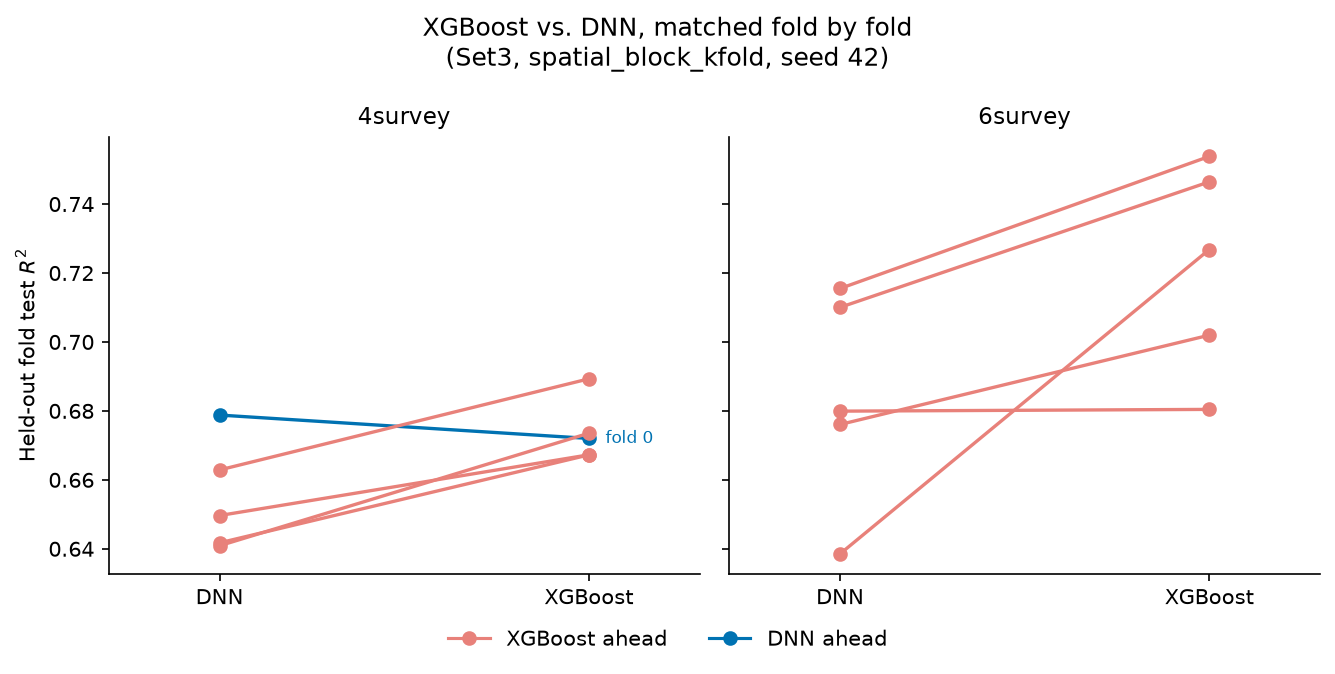

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)

for ax, cohort in zip(axes, COHORTS):
    dnn_vals = per_fold_r2[cohort]["DNN"]
    xgb_vals = per_fold_r2[cohort]["XGBoost"]
    for fold_index, (dnn_r2, xgb_r2) in enumerate(zip(dnn_vals, xgb_vals)):
        winner_color = COLOR_XGBOOST if xgb_r2 > dnn_r2 else COLOR_DNN
        ax.plot([0, 1], [dnn_r2, xgb_r2], color=winner_color, marker="o",
                markersize=6, linewidth=1.6, zorder=2)
        if xgb_r2 <= dnn_r2:
            # The one reversed fold (if any) is the figure's must-not-miss detail -- label it
            # directly rather than leaving the reader to spot it among five near-identical lines.
            ax.annotate(f"fold {fold_index}", xy=(1, xgb_r2), xytext=(8, 0),
                        textcoords="offset points", fontsize=8, va="center", color=COLOR_DNN)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["DNN", "XGBoost"])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(cohort, fontsize=11)

axes[0].set_ylabel("Held-out fold test $R^2$")

legend_handles = [
    plt.Line2D([0], [0], color=COLOR_XGBOOST, marker="o", label="XGBoost ahead"),
    plt.Line2D([0], [0], color=COLOR_DNN, marker="o", label="DNN ahead"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.suptitle("XGBoost vs. DNN, matched fold by fold\n(Set3, spatial_block_kfold, seed 42)",
             fontsize=12)
plt.tight_layout()
plt.show()

## Figure R1-2 (optional) -- how split difficulty changes each model's apparent accuracy

**Research question**: RQ1 items 3-4 -- how much does a model's apparent accuracy change as the
evaluation design gets progressively harder to leak into (plot-level -> spatial-block (single
split) -> temporal), and does that change differ between DNN and the physics-guided models?

**Data source note**: the single-split numbers behind this figure are reported in
`TEMP_results/TEMP_rq1_plotlevel_check_results_2026-08-12.tex` and
`TEMP_results/TEMP_rq1_temporalcheck_results_2026-08-11.tex`. This cell transcribes those
already-verified numbers directly (cited by source file) rather than re-reading raw per-model
`predictions.csv`/`metrics.json` files, since this session did not verify those single-split runs'
exact output-directory names. **For a stricter, file-verified version**: confirm each run's
`model_output_dir(...)` path and replace the hardcoded dict below with a direct read.
PINN_k's own plot_level/temporal numbers were not separately itemised in the source text (only
"PINN and PINN_k inflate by 0.006 or less on either cohort" as a combined statement) -- PINN_k is
therefore approximated here as equal to PINN; flagged in the plot caption, not silently assumed.

**Encoding**: one panel per cohort, one line per model (DNN, PINN, PINN_k) across the 3 ordered
split-difficulty categories. No uncertainty shown -- these are single-split point values with no
fold repeats; the axis label says so explicitly so this is never confused with the pooled
`spatial_block_kfold` table elsewhere in the chapter.

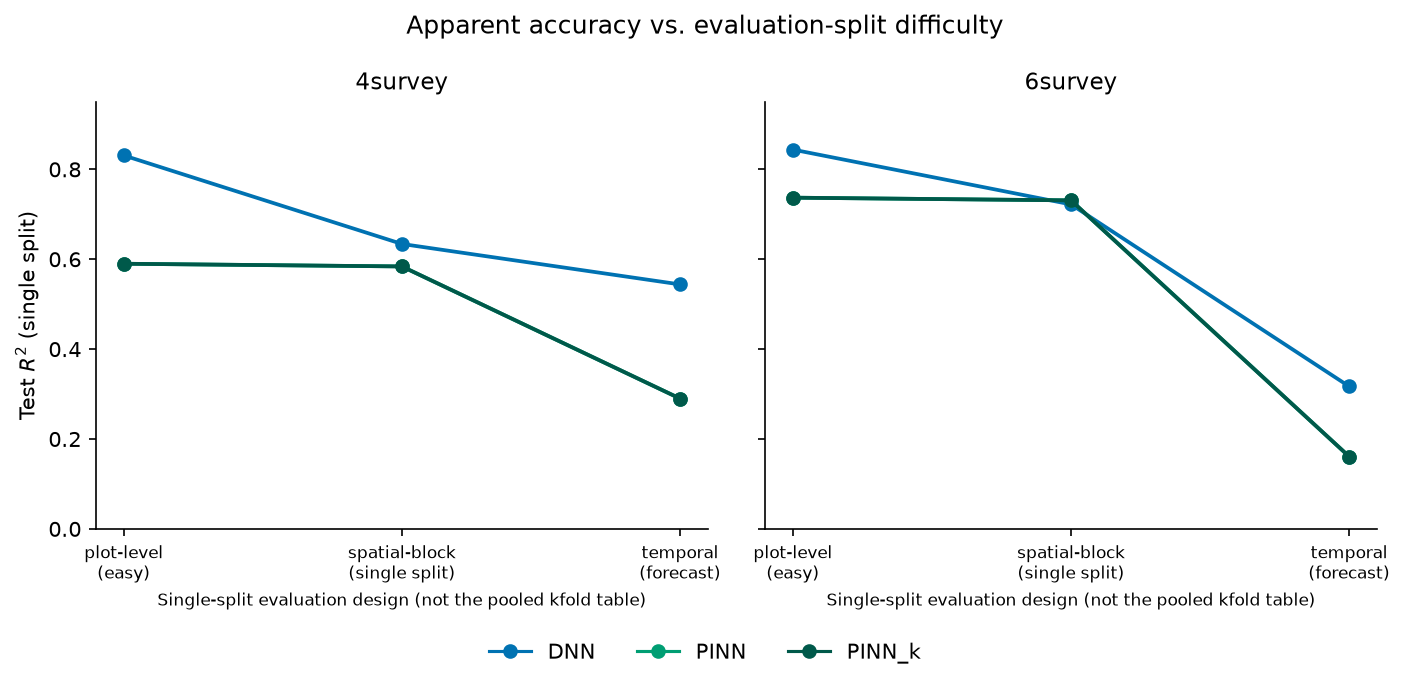

In [5]:
from notebooks.results_figures_style import COLOR_DNN, COLOR_PINN, COLOR_PINN_K

# Transcribed from TEMP_rq1_plotlevel_check_results_2026-08-12.tex and
# TEMP_rq1_temporalcheck_results_2026-08-11.tex -- see the markdown cell above for why these are
# hardcoded rather than read live.
SPLIT_R2 = {
    "4survey": {
        "DNN":    {"plot_level": 0.831, "spatial_block": 0.634, "temporal": 0.544},
        "PINN":   {"plot_level": 0.590, "spatial_block": 0.584, "temporal": 0.290},
        "PINN_k": {"plot_level": 0.590, "spatial_block": 0.584, "temporal": 0.290},  # approximated as == PINN, see note above
    },
    "6survey": {
        "DNN":    {"plot_level": 0.844, "spatial_block": 0.722, "temporal": 0.317},
        "PINN":   {"plot_level": 0.737, "spatial_block": 0.731, "temporal": 0.161},
        "PINN_k": {"plot_level": 0.737, "spatial_block": 0.731, "temporal": 0.161},  # approximated as == PINN, see note above
    },
}
SPLIT_ORDER = ["plot_level", "spatial_block", "temporal"]
SPLIT_LABELS = ["plot-level\n(easy)", "spatial-block\n(single split)", "temporal\n(forecast)"]
MODEL_COLORS_R1 = {"DNN": COLOR_DNN, "PINN": COLOR_PINN, "PINN_k": COLOR_PINN_K}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), sharey=True)
for ax, cohort in zip(axes, COHORTS):
    for model, color in MODEL_COLORS_R1.items():
        values = [SPLIT_R2[cohort][model][s] for s in SPLIT_ORDER]
        ax.plot(range(3), values, marker="o", color=color, label=model, linewidth=1.8)
    ax.set_xticks(range(3))
    ax.set_xticklabels(SPLIT_LABELS, fontsize=8)
    ax.set_title(cohort, fontsize=11)
    ax.set_xlabel("Single-split evaluation design (not the pooled kfold table)", fontsize=8)

axes[0].set_ylabel("Test $R^2$ (single split)")
axes[0].set_ylim(0, 0.95)
fig.legend(handles=[plt.Line2D([0], [0], color=c, marker="o", label=m) for m, c in MODEL_COLORS_R1.items()],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Apparent accuracy vs. evaluation-split difficulty", fontsize=12)
plt.tight_layout()
plt.show()